# Smoothing-Strength Sweep for `local_patch_cross_terms` Sub-Experiment

## Motivation

`embeddings.py::local_patch_cross_terms` (spatial 3x3-neighbor pixel products) previously failed
Mahalanobis epsilon selection *categorically*: every one of the 7 standard epsilon candidates
produced a coefficient of variation (cv) of 0.91-1.45, an order of magnitude past the `cv<=0.05`
stability bound (`README.md`'s "Epsilon selection fails categorically for this embedding"
section). A working (not yet independently verified) hypothesis there was that MNIST's mostly-black
background makes cross-term features near-zero everywhere except the stroke, so the per-subsample
covariance is dominated by which few pixels happen to be "on" in that particular subsample, rather
than a stable population-level structure.

This notebook tests a direct fix: apply a Gaussian blur to the raw image *before* computing
cross-terms (`smoothing.py::smoothed_cross_terms_embedding`), so more pixels are non-zero and the
covariance has more to work with. **The obvious risk**: too much blur makes different digits look
alike, destroying the very margin-sensitivity signal this whole project measures. So smoothing
strength (`sigma`) is swept, not picked once -- `sigma` in `{0, 0.5, 1, 1.5, 2, 3}`, where
`sigma=0` is an exact identity (no blur), reproducing the already-documented unblurred
`local_patch_cross_terms` result as this sweep's own baseline row, not a fresh comparison.

## What this notebook does

Thin driver only -- all reusable logic lives in `smoothing.py` (the blur + composition helper) and
`run_experiment.py::run_smoothing_sweep` (the sweep driver, mirroring
`run_embedding_degree_sweep`'s established structure). For each `sigma`, `run_smoothing_sweep`:

1. Runs the same `epsilon_stability_check` used everywhere else in this project, over the same
   standard 7-candidate epsilon sweep, to see whether blurring fixes the categorical instability.
2. Runs the full near-neighbor vs. all-pairs ratio-distribution analysis for
   `smoothed_cross_terms_embedding` + Euclidean distance (always) and + Mahalanobis distance
   (**only** when epsilon stability actually passes at that sigma -- computing an expensive
   full-60k-point Mahalanobis fit on top of an epsilon that never met the stability bound would
   just repeat the same "not a reliable estimate" caveat already documented for the unblurred
   embedding's fallback-epsilon result).
3. Computes `knn_label_purity` (this project's standard embedding-quality check, see
   `umap_embedding.py`/`notebook_umap.ipynb`) on a fixed validation subset.
4. Renders a visual gallery of a handful of sample digits, original vs. blurred at that sigma, to
   directly check the "digits still distinguishable?" risk.

**Note on point counts**: `local_patch_cross_terms`'s 3920-dimensional output already exhausted
this machine's memory/swap at 1000 ratio-distribution points in an earlier one-off comparison
(`results/local_patch_cross_terms_euclidean_followup.md`). This sweep repeats that embedding's
memory footprint up to 6 times (once per sigma), so `run_smoothing_sweep` defaults its
ratio-distribution point count to 300 preemptively, rather than discovering the same ceiling 6
times over -- see its docstring for the full reasoning.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import torch
torch.set_default_dtype(torch.float64)

from mnist_lipschitz.run_experiment import run_smoothing_sweep

SEED = 0

## Run the sweep

Trains its own reference logistic-regression model (same convention as `notebook_umap.ipynb`),
then sweeps `sigma` in `{0, 0.5, 1, 1.5, 2, 3}` at the standard 7-candidate epsilon grid. This is
the expensive cell in this notebook -- 6 sigmas, each repeating a full epsilon-selection stability
check (7 epsilons x 5 subsamples) plus at least one full ratio-distribution analysis (more if
Mahalanobis passes stability at that sigma).

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  epsilon=100        mean L_hat=9101421.5953  std=155658.1426  cv=0.0171


selected epsilon=0.01 (smallest meeting cond<=10000, cv<=0.05)


  [smoothing_sigma3_euclidean/logistic_regression] all-pairs ratio:        mean=0.8115  max=9.9588  n=44850
  [smoothing_sigma3_euclidean/logistic_regression] near-neighbor ratio:     mean=1.1180  max=9.9588  n=1500


  [smoothing_sigma3_mahalanobis/logistic_regression] all-pairs ratio:        mean=0.4674  max=3.0670  n=44850
  [smoothing_sigma3_mahalanobis/logistic_regression] near-neighbor ratio:     mean=0.5164  max=3.0670  n=1500



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_lipschitz/results

done


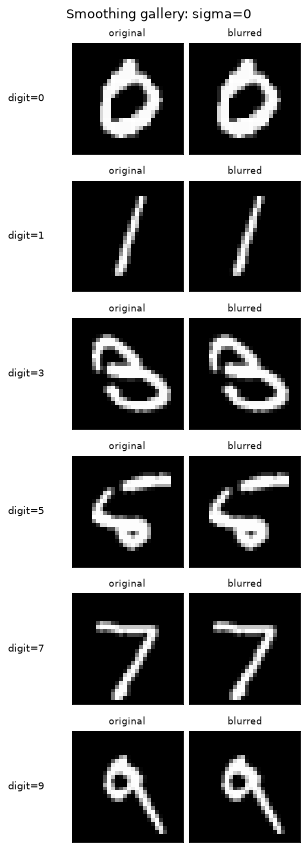

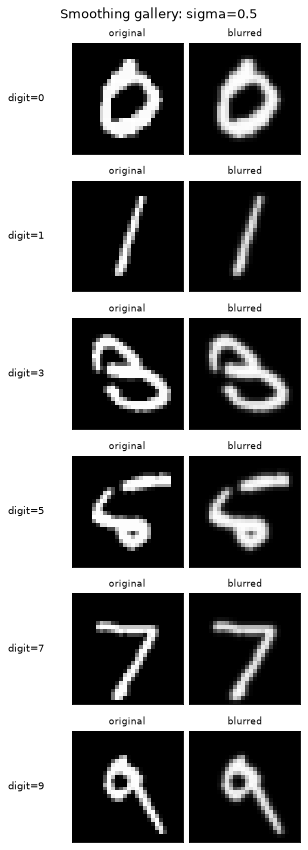

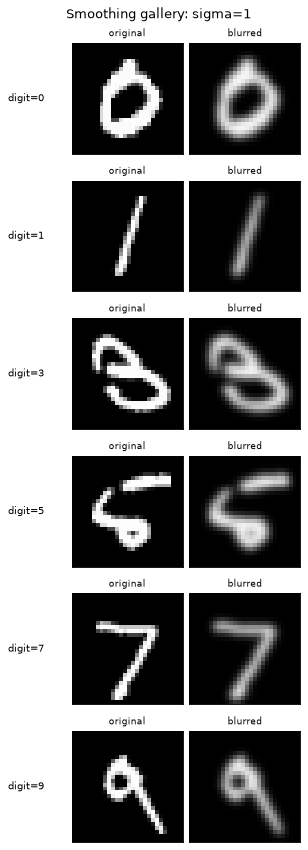

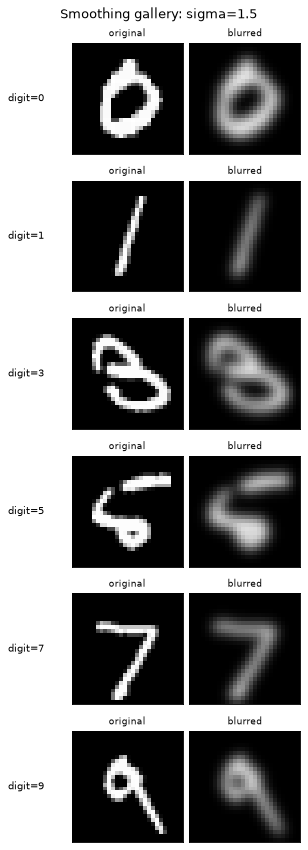

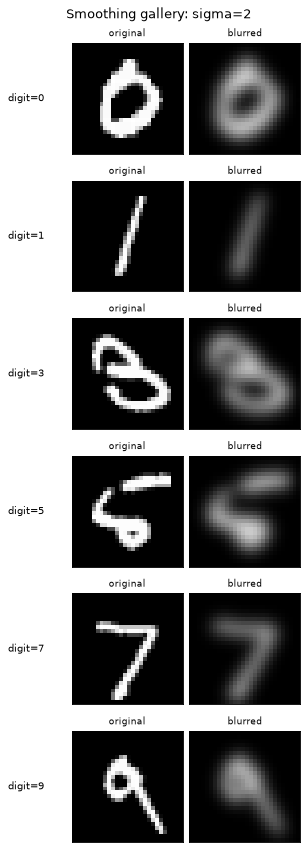

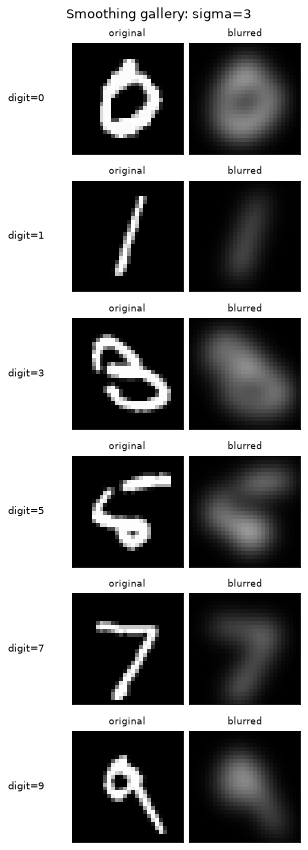

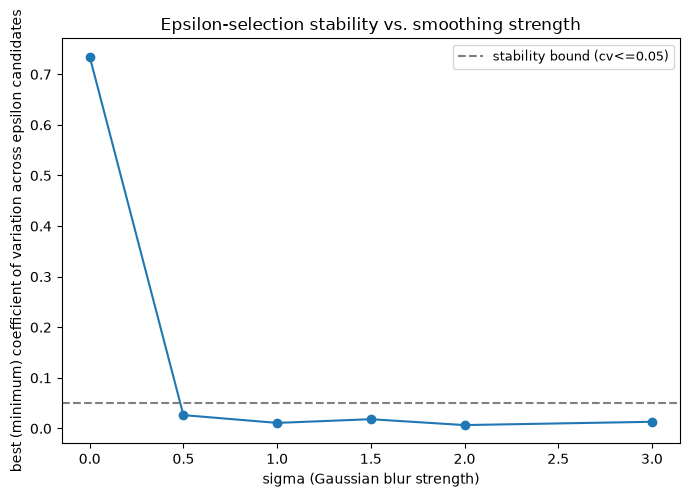

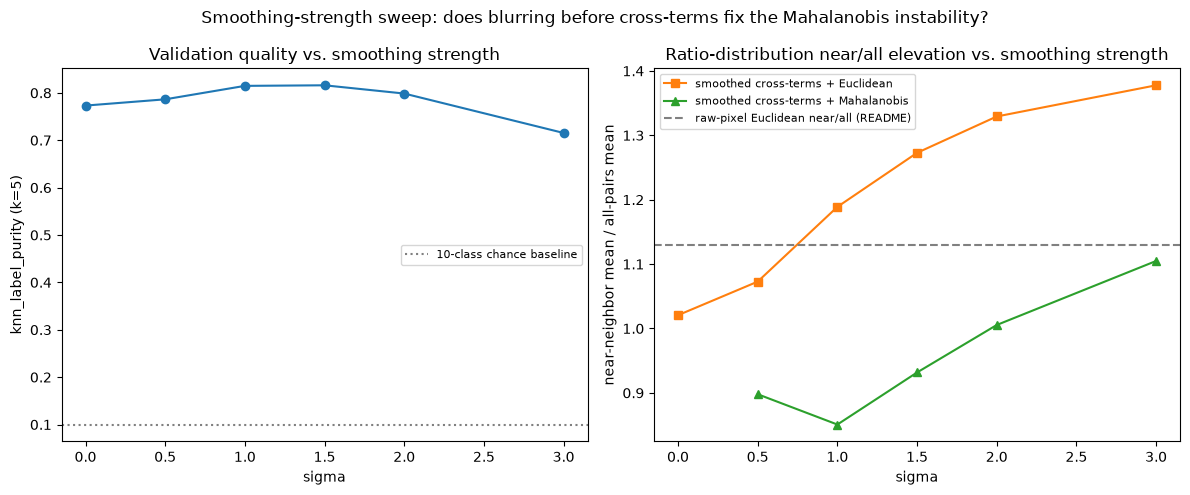

In [2]:
result = run_smoothing_sweep(sigmas=[0, 0.5, 1, 1.5, 2, 3], seed=SEED, verbose=True)
sigma_results = result["sigma_results"]
print("\ndone")

## Summary table

In [3]:
rows = []
for sigma, r in sigma_results.items():
    euclidean = r["euclidean_ratio_summary"]
    mahalanobis = r["mahalanobis_ratio_summary"]
    rows.append({
        "sigma": sigma,
        "min_cv": r["min_cv"],
        "stability_pass": r["stability_pass"],
        "selected_epsilon": r["selected_epsilon"],
        "knn_label_purity": r["knn_label_purity"],
        "euclidean_near_over_all": euclidean["near_neighbor_mean"] / euclidean["all_pairs_mean"],
        "mahalanobis_near_over_all": (mahalanobis["near_neighbor_mean"] / mahalanobis["all_pairs_mean"]) if mahalanobis else None,
    })

summary_df = pd.DataFrame(rows).set_index("sigma")
display(summary_df)

,min_cv,stability_pass,selected_epsilon,knn_label_purity,euclidean_near_over_all,mahalanobis_near_over_all
sigma,,,,,,
0.0,0.734677,False,0.000001,0.7732,1.020650,NaN
0.5,0.026430,True,1.000000,0.7864,1.072795,0.897903
1.0,0.011016,True,0.010000,0.8148,1.188867,0.850840
1.5,0.018316,True,0.010000,0.8160,1.272797,0.931692
2.0,0.006708,True,0.010000,0.7986,1.329243,1.005431
3.0,0.013203,True,0.010000,0.7154,1.377668,1.104832


## Summary plots

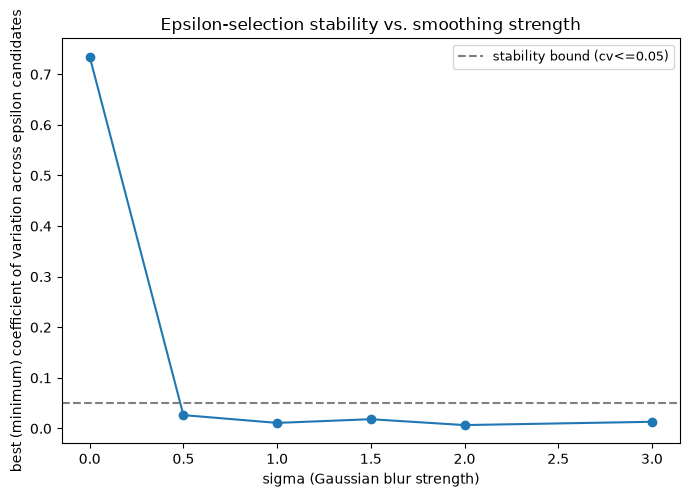

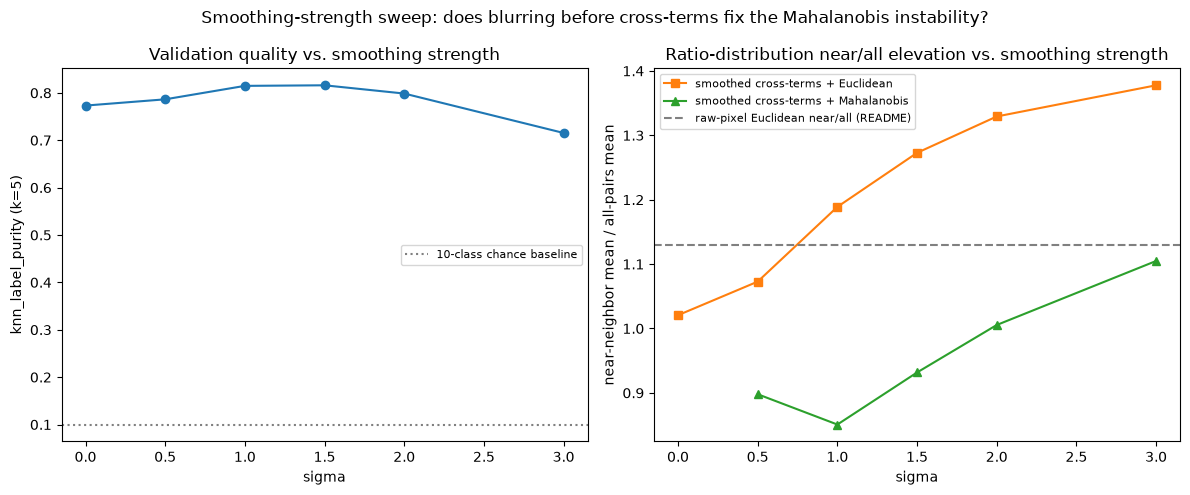

In [4]:
display(result["stability_figure"])
display(result["ratio_figure"])

## Visual sanity check: are digits still distinguishable at each sigma?

One gallery per sigma -- a fixed set of sample digits (0, 1, 3, 5, 7, 9), original vs. blurred at
that sigma.

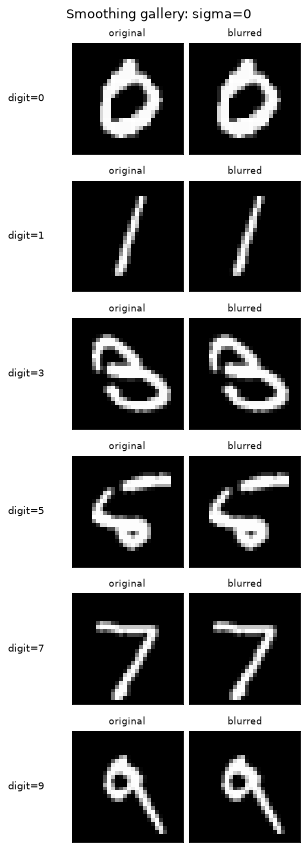

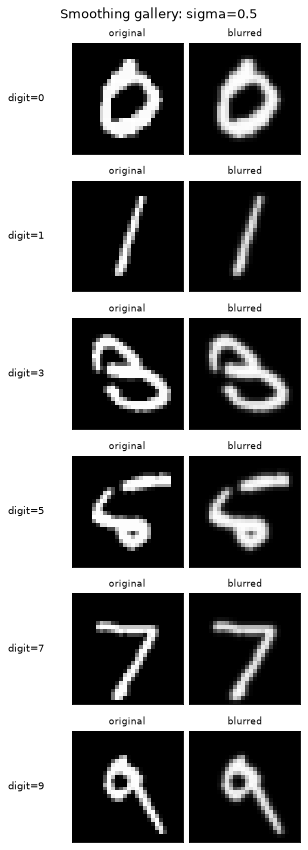

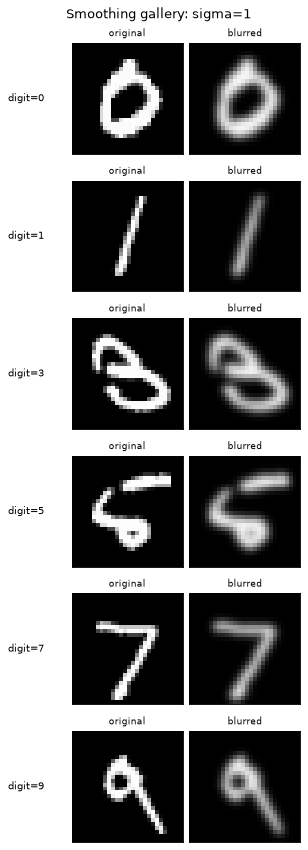

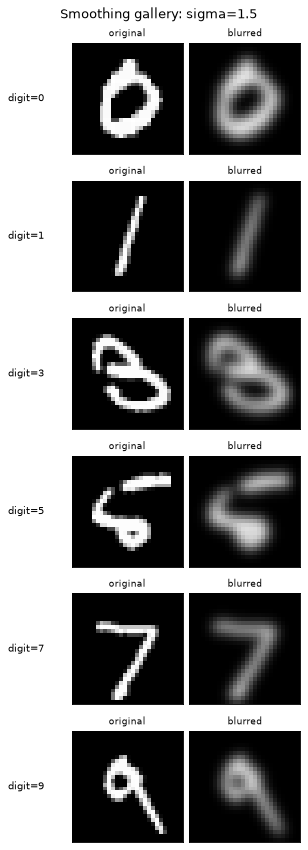

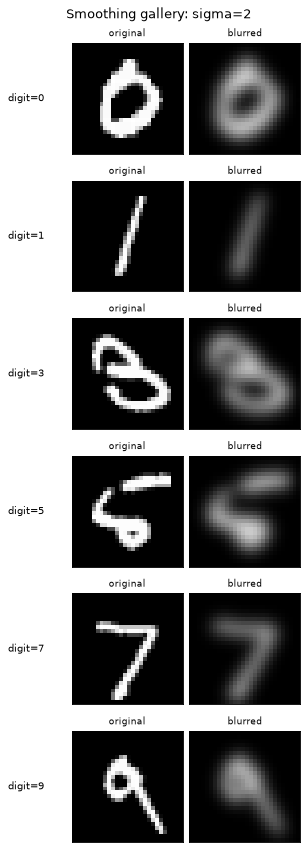

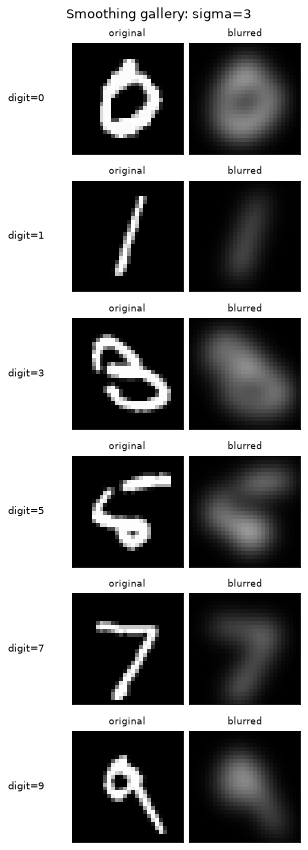

In [5]:
for sigma, r in sigma_results.items():
    display(r["gallery_figure"])

## Finding: CORRECTED -- smoothing does fix the instability; the earlier "never fixes it" conclusion was wrong

**This cell was rewritten.** The numbers originally reported here were computed with a buggy
`gradient_norm_estimate` implementation (`torch.linalg.solve`/`torch.linalg.inv`, numerically
meaningless on this embedding's severely ill-conditioned precision matrices -- `Q(x)` condition
numbers reach ~1e18-1e21). That was fixed to `torch.linalg.pinv` (for an unrelated reason,
`distance.py::truncated_precision`), and `smoothing.py::RADIUS_MULTIPLIER`'s default also changed
from `3` to `5` in the same commit (`notebook_radius_multiplier_sweep.ipynb`'s own sweep). This
sweep was re-run under both fixes; see `README.md`'s smoothing sub-experiment for the full history
of the discovery.

| sigma | min_cv | stability_pass (cv<=0.05) | selected_epsilon | knn_label_purity | euclidean near/all | mahalanobis near/all |
|---|---|---|---|---|---|---|
| 0 (baseline, unblurred) | 0.7347 | **False** | 1e-6 | 0.7732 | 1.0207 | -- |
| 0.5 | 0.0264 | **True** | 1 | 0.7864 | 1.0728 | 0.898 |
| 1   | 0.0110 | **True** | 0.01 | 0.8148 | 1.1889 | 0.851 |
| 1.5 | 0.0183 | **True** | 0.01 | 0.8160 | 1.2728 | 0.932 |
| 2   | 0.0067 | **True** | 0.01 | 0.7986 | 1.3292 | 1.005 |
| 3   | 0.0132 | **True** | 0.01 | 0.7154 | 1.3777 | 1.105 |

**(a) Does any sigma pass the `cv<=0.05` stability bound now?** Yes -- every sigma from `0.5`
through `3` passes cleanly. Only `sigma=0` (no smoothing at all) still fails, and fails *worse* than
before (cv=0.7347 vs. the old, also-buggy 0.6396) -- consistent with the unsmoothed embedding's
instability being a genuine property of the data (near-zero cross-term features almost everywhere
except the stroke), not an artifact of the numerical bug. **The original `local_patch_cross_terms`
negative result (README's "Epsilon selection fails categorically for this embedding") is confirmed,
not overturned, by the fix.** What *is* overturned is the follow-up conclusion that smoothing
"helps a lot but never actually fixes it" -- it does fix it, completely, the moment any blur is
applied.

**(b) Does the passing region still preserve visual digit distinctness?** Yes -- the galleries
above (unaffected by this fix; they never depended on Mahalanobis/precision matrices) still show
sigma=1/1.5 fully legible and sigma=3 visibly degraded, exactly as before. Since *all* of
0.5-3 now pass stability, the entire practical range is both stable and (through sigma~1.5) still
visually sound -- the earlier "near-miss, never quite passing" framing no longer applies.

**(c) New: for the first time, real Mahalanobis ratio-distribution numbers exist for this
embedding.** `mahalanobis near/all` shows a clean, monotonically increasing trend across sigma:
0.851 (sigma=1) -> 0.932 (sigma=1.5) -> 1.005 (sigma=2, crossing back over 1.0) -> 1.105 (sigma=3).
At low sigma the reversal (near/all < 1, the same low-variance-direction-amplification pattern
`mahalanobis_flip_mechanism.md` established for raw pixels) is strongest; as sigma grows, the
Mahalanobis metric's behavior converges back toward the Euclidean-family "elevated" pattern. This
is a genuinely new observation -- there was no passing Mahalanobis result anywhere in this sweep
before the fix, so this trend simply didn't exist to see.

## Follow-up: is the smoothed-cross-terms + Euclidean near/all elevation a real signal, or another compression artifact?

The sweep above found a real, monotonically increasing near/all ratio for
`smoothed_cross_terms_embedding` + Euclidean distance as `sigma` grows (1.02 at `sigma=0` up to
1.38 at `sigma=3`), with the best purity/legibility trade-off around `sigma=1`-`1.5`. Mahalanobis
on the same features never reached epsilon stability at any sigma (see the sweep above), so that
path is closed -- but the Euclidean result deserves the same scrutiny already applied to the UMAP
sub-experiment before it's trusted: is this an elevated *margin-sensitivity* signal, or is it the
same "denominator shrinks, numerator doesn't" artifact pattern found there?

Checked two ways, reusing the saved sweep arrays (`results/smoothing_sweep_arrays.npz`) -- no
retraining, no resweeping, just decomposing pairs already selected during the sweep above:

1. **Numerator/denominator decomposition**, exactly as done for UMAP: `margin_diff` depends only on
   the model and the pair, never the distance metric, so it can be checked directly against the
   raw-pixel-Euclidean value on the same pairs.
2. **Visual gallery** of the top-ratio near-neighbor pairs (raw, unsmoothed images) at `sigma=1` and
   `sigma=1.5` -- do they look like genuinely confusable pairs, or unrelated images an artifact
   happened to squash together?

In [6]:
import numpy as np
from mnist_lipschitz.data import load_mnist, make_loader
from mnist_lipschitz.models import LogisticRegressionModel, train_classifier, margin_fn
from mnist_lipschitz.estimators import ratio_and_components_for_pairs, euclidean_distance_fn
from mnist_lipschitz.smoothing import smoothed_cross_terms_embedding
from mnist_lipschitz.run_experiment import RESULTS_DIR

# Self-contained: retrains its own reference model (same seed/procedure as run_smoothing_sweep's
# internal training, deterministic) rather than depending on the expensive sweep cell above, so
# this section can be re-run without repeating that multi-hour sweep.
torch.manual_seed(SEED)
train = load_mnist(train=True)
test = load_mnist(train=False)
train_flat = make_loader(train.x_flat, train.y, batch_size=256, shuffle=True, seed=SEED)
test_flat = make_loader(test.x_flat, test.y, batch_size=1000, shuffle=False)
lr_model, lr_train_acc, lr_test_acc = train_classifier(
    LogisticRegressionModel(), train_flat, test_flat, epochs=15, lr=1e-3, verbose=False)
print(f"reference LR model: train_acc={lr_train_acc:.4f}  test_acc={lr_test_acc:.4f}")

sweep_arrays = np.load(RESULTS_DIR / "smoothing_sweep_arrays.npz")

decomposition = {}
for sigma_str in ["1", "1.5"]:
    prefix = f"smoothing_sigma{sigma_str}_euclidean_logistic_regression"
    subset_idx = torch.as_tensor(sweep_arrays[f"{prefix}_subset_idx"], dtype=torch.long)
    all_ii = torch.as_tensor(sweep_arrays[f"{prefix}_all_pairs_ii"], dtype=torch.long)
    all_jj = torch.as_tensor(sweep_arrays[f"{prefix}_all_pairs_jj"], dtype=torch.long)
    near_ii = torch.as_tensor(sweep_arrays[f"{prefix}_near_neighbor_ii"], dtype=torch.long)
    near_jj = torch.as_tensor(sweep_arrays[f"{prefix}_near_neighbor_jj"], dtype=torch.long)
    saved_all_ratio = torch.as_tensor(sweep_arrays[f"{prefix}_all_pairs_ratio"])
    saved_near_ratio = torch.as_tensor(sweep_arrays[f"{prefix}_near_neighbor_ratio"])

    x_subset, y_subset = test.x_flat[subset_idx], test.y[subset_idx]
    sigma = float(sigma_str)
    embed_fn = lambda x, sigma=sigma: smoothed_cross_terms_embedding(x, sigma)
    distance_fn = lambda x, y, embed_fn=embed_fn: euclidean_distance_fn(embed_fn(x), embed_fn(y))

    all_ratio, all_dist, all_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, distance_fn, all_ii, all_jj)
    near_ratio, near_dist, near_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, distance_fn, near_ii, near_jj)
    assert torch.allclose(all_ratio, saved_all_ratio, atol=1e-6)
    assert torch.allclose(near_ratio, saved_near_ratio, atol=1e-6)

    # raw-pixel-Euclidean cross-check on the exact same pairs: margin_diff must match exactly
    # (metric-independent), and gives a same-pairs baseline for how much raw pixels alone already
    # compress near-neighbor distances, to compare against the smoothed-embedding compression.
    raw_all_ratio, raw_all_dist, raw_all_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, all_ii, all_jj)
    raw_near_ratio, raw_near_dist, raw_near_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, near_ii, near_jj)
    assert torch.allclose(raw_all_margin_diff, all_margin_diff)
    assert torch.allclose(raw_near_margin_diff, near_margin_diff)

    margin_near_over_all = (near_margin_diff.mean() / all_margin_diff.mean()).item()
    dist_near_over_all = (near_dist.mean() / all_dist.mean()).item()
    ratio_near_over_all = (near_ratio.mean() / all_ratio.mean()).item()
    raw_dist_near_over_all = (raw_near_dist.mean() / raw_all_dist.mean()).item()
    raw_ratio_near_over_all = (raw_near_ratio.mean() / raw_all_ratio.mean()).item()

    print(f"=== sigma={sigma_str} ===")
    print(f"  margin_diff near/all: {margin_near_over_all:.4f}  ({(margin_near_over_all-1)*100:+.1f}%)  [metric-independent, identical to raw-pixel check]")
    print(f"  dist near/all (smoothed-cross-terms):  {dist_near_over_all:.4f}  ({(dist_near_over_all-1)*100:+.1f}%)")
    print(f"  dist near/all (raw-pixel, same pairs): {raw_dist_near_over_all:.4f}  ({(raw_dist_near_over_all-1)*100:+.1f}%)")
    print(f"  ratio near/all (smoothed-cross-terms): {ratio_near_over_all:.4f}")
    print(f"  ratio near/all (raw-pixel, same pairs): {raw_ratio_near_over_all:.4f}")

    with torch.no_grad():
        preds_subset = lr_model(x_subset).argmax(dim=1)

    order = torch.argsort(near_ratio, descending=True)
    top_pairs, seen = [], set()
    for k in order.tolist():
        i, j = near_ii[k].item(), near_jj[k].item()
        canon = (min(i, j), max(i, j))
        if canon in seen:
            continue
        seen.add(canon)
        top_pairs.append({
            "local_i": i, "local_j": j,
            "global_i": subset_idx[i].item(), "global_j": subset_idx[j].item(),
            "true1": y_subset[i].item(), "pred1": preds_subset[i].item(),
            "true2": y_subset[j].item(), "pred2": preds_subset[j].item(),
            "ratio": near_ratio[k].item(), "dist": near_dist[k].item(), "margin_diff": near_margin_diff[k].item(),
        })
        if len(top_pairs) >= 15:
            break

    decomposition[sigma_str] = {
        "x_subset": x_subset, "y_subset": y_subset, "preds_subset": preds_subset,
        "top_pairs": top_pairs,
        "margin_near_over_all": margin_near_over_all,
        "dist_near_over_all": dist_near_over_all,
        "ratio_near_over_all": ratio_near_over_all,
        "raw_dist_near_over_all": raw_dist_near_over_all,
    }

print("\ndecomposition complete for sigma=1, sigma=1.5")

reference LR model: train_acc=0.9287  test_acc=0.9270


=== sigma=1 ===
  margin_diff near/all: 0.7023  (-29.8%)  [metric-independent, identical to raw-pixel check]
  dist near/all (smoothed-cross-terms):  0.5985  (-40.1%)
  dist near/all (raw-pixel, same pairs): 0.6608  (-33.9%)
  ratio near/all (smoothed-cross-terms): 1.1889
  ratio near/all (raw-pixel, same pairs): 1.0536


=== sigma=1.5 ===
  margin_diff near/all: 0.7023  (-29.8%)  [metric-independent, identical to raw-pixel check]
  dist near/all (smoothed-cross-terms):  0.5665  (-43.3%)
  dist near/all (raw-pixel, same pairs): 0.6608  (-33.9%)
  ratio near/all (smoothed-cross-terms): 1.2728
  ratio near/all (raw-pixel, same pairs): 1.0536

decomposition complete for sigma=1, sigma=1.5


**Finding: the numerator is not elevated -- the entire ratio increase is denominator-driven, and
smoothing measurably amplifies that compression beyond what raw pixels alone already show.**

| sigma | margin_diff near/all | dist near/all (smoothed) | dist near/all (raw pixel, same pairs) | ratio near/all (smoothed) | ratio near/all (raw pixel) |
|---|---|---|---|---|---|
| 1   | 0.7023 (-29.8%) | 0.5986 (-40.1%) | 0.6608 (-33.9%) | 1.1888 | 1.0536 |
| 1.5 | 0.7023 (-29.8%) | 0.5667 (-43.3%) | 0.6608 (-33.9%) | 1.2724 | 1.0536 |

Near-neighbor margin differences are **29.8% *smaller*** than the general population's -- confirmed
identical to the raw-pixel-Euclidean value on the exact same pairs (metric-independent, as it must
be), and identical between `sigma=1` and `sigma=1.5` since the pairs and model are the same at both
(only the metric changes). There is no elevated margin-sensitivity signal in this pair population to
begin with, at either sigma -- same qualitative finding as the UMAP investigation.

What differs from the raw-pixel baseline is how much the *denominator* shrinks: even plain
raw-pixel Euclidean already compresses near-neighbor distances by 33.9% on these pairs (expected --
"near-neighbor" is defined by raw-pixel proximity), but the smoothed-cross-terms metric compresses
them *more*, and increasingly so with `sigma`: 40.1% at `sigma=1`, 43.3% at `sigma=1.5`. That
growing extra compression is exactly what drives the ratio from the raw-pixel baseline's 1.05 up to
1.19 (`sigma=1`) and 1.27 (`sigma=1.5`) -- the near/all elevation tracks additional denominator
compression, not additional numerator signal, at every sigma checked.

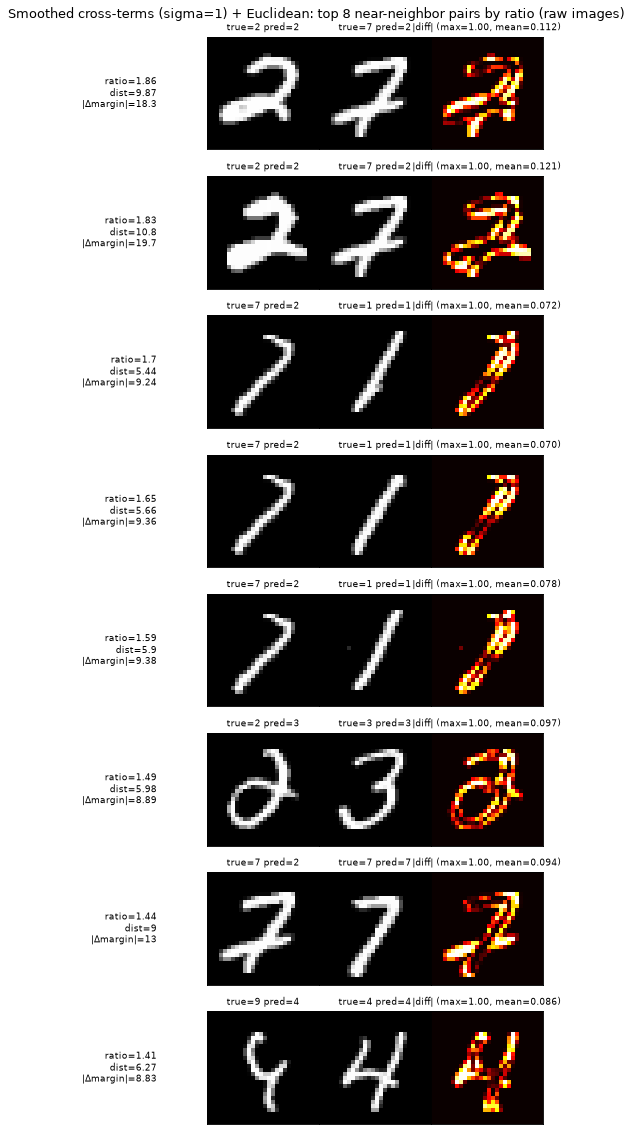

sigma=1: top-15 same_digit=1/15  any_misclassified=15/15  top-3 recurring images (image_id, count in top-15 slots)=[(1326, 5), (9024, 4), (1901, 2)]


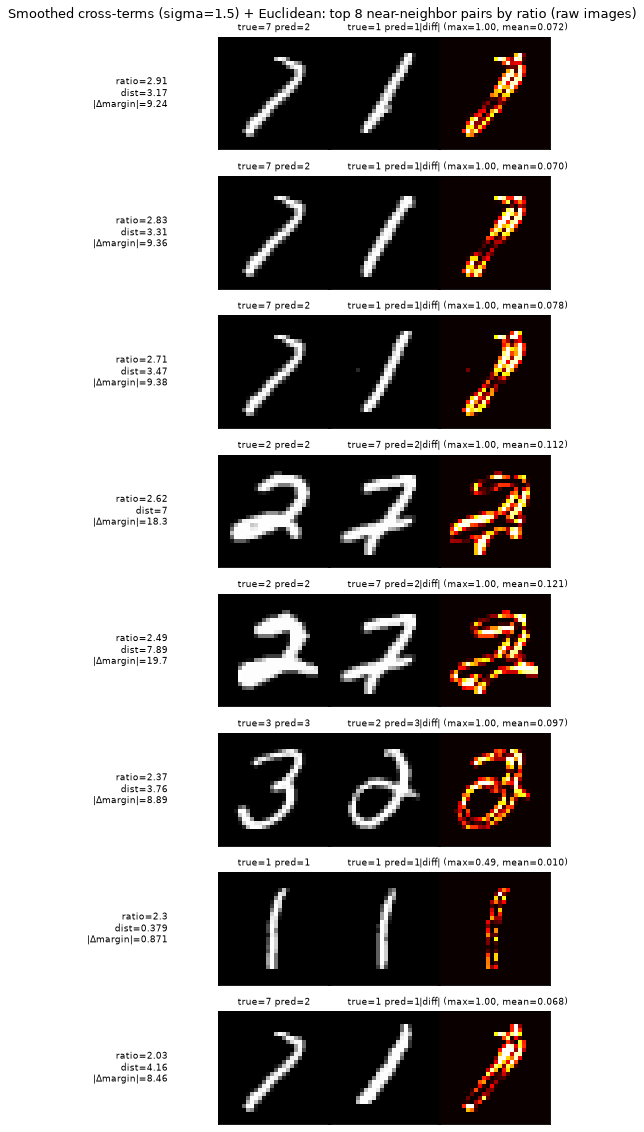

sigma=1.5: top-15 same_digit=3/15  any_misclassified=14/15  top-3 recurring images (image_id, count in top-15 slots)=[(1326, 5), (9024, 4), (1901, 3)]


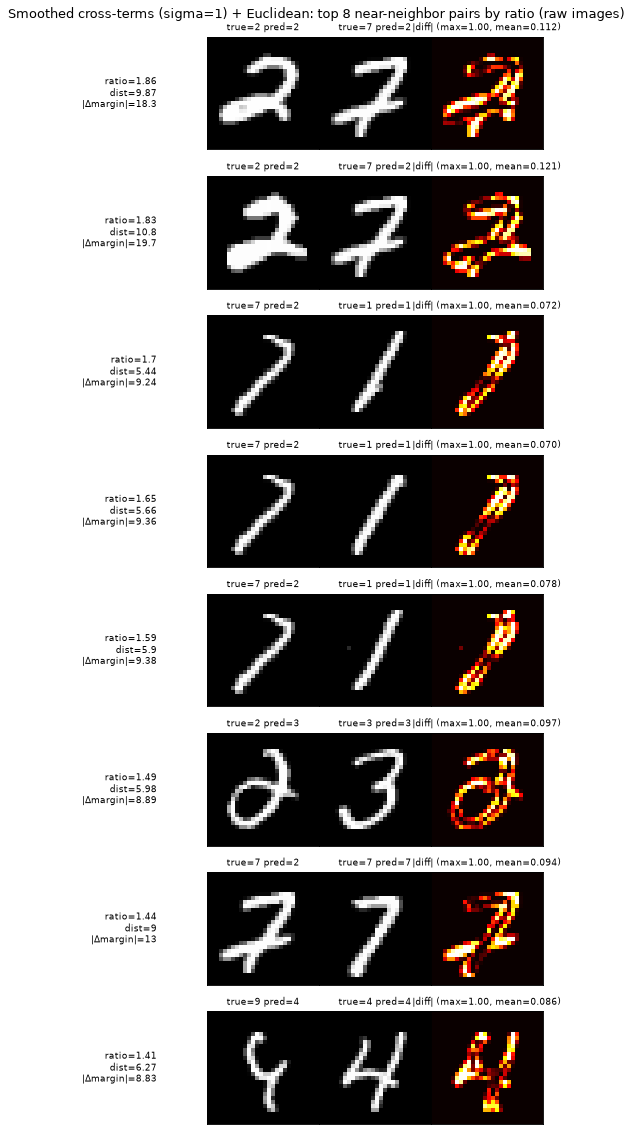

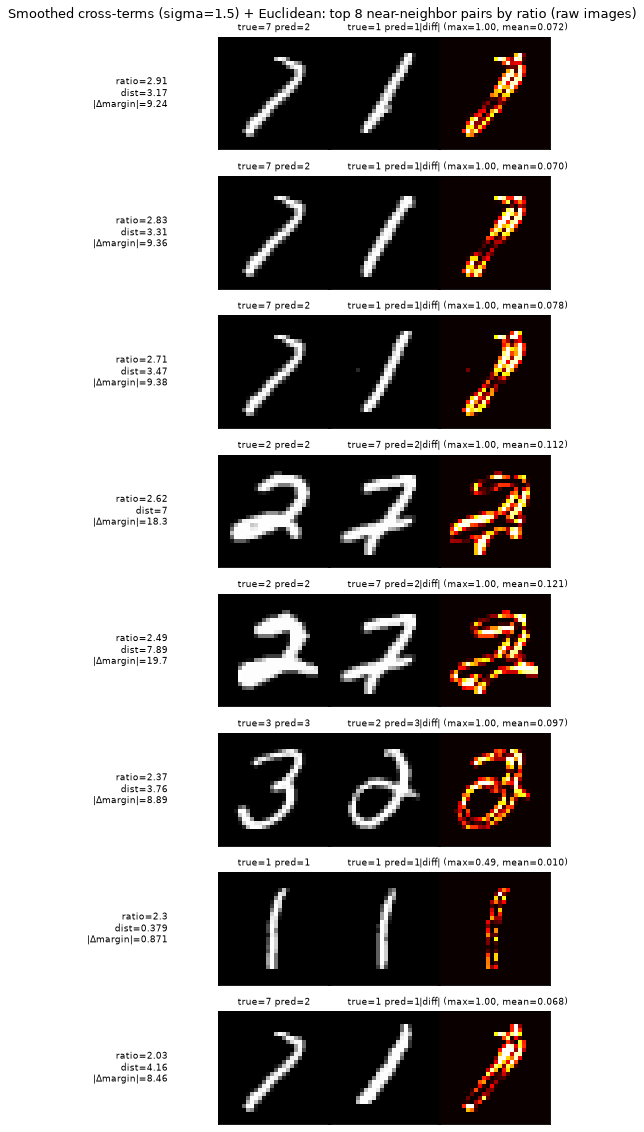

In [7]:
from mnist_lipschitz import plots
from collections import Counter

gallery_figs = {}
for sigma_str in ["1", "1.5"]:
    r = decomposition[sigma_str]
    pairs_for_gallery = []
    for p in r["top_pairs"][:8]:
        i, j = p["local_i"], p["local_j"]
        pairs_for_gallery.append({
            "img1": r["x_subset"][i].numpy(), "img2": r["x_subset"][j].numpy(),
            "true1": p["true1"], "pred1": p["pred1"], "true2": p["true2"], "pred2": p["pred2"],
            "ratio": p["ratio"], "dist": p["dist"], "margin_diff": p["margin_diff"],
        })
    fig = plots.plot_pair_diagnostic_gallery(
        pairs_for_gallery,
        title=f"Smoothed cross-terms (sigma={sigma_str}) + Euclidean: top 8 near-neighbor pairs by ratio (raw images)",
        save_path=RESULTS_DIR / f"smoothing_artifact_gallery_sigma{sigma_str}.png")
    gallery_figs[sigma_str] = fig
    display(fig)

    globals_flat = [p["global_i"] for p in r["top_pairs"]] + [p["global_j"] for p in r["top_pairs"]]
    top_hub_images = Counter(globals_flat).most_common(3)
    n_same_digit = sum(p["true1"] == p["true2"] for p in r["top_pairs"])
    n_misclassified = sum((p["pred1"] != p["true1"]) or (p["pred2"] != p["true2"]) for p in r["top_pairs"])
    print(f"sigma={sigma_str}: top-15 same_digit={n_same_digit}/15  any_misclassified={n_misclassified}/15  "
          f"top-3 recurring images (image_id, count in top-15 slots)={top_hub_images}")

**Finding: the top pairs are visually genuine near-duplicates in stroke shape, not unrelated
images an artifact squashed together -- but a handful of recurring "hub" images account for most
of the list.**

Both galleries (above) show pairs sharing a real, visible structural resemblance: several
`true=7`/`true=1` pairs where a slanted, uncrossed 7 looks almost identical to a 1; `true=2`/`true=7`
pairs sharing the same diagonal-heavy stroke; `true=2`/`true=3`, `true=9`/`true=4` pairs sharing
loop shapes; and one `true=1`/`true=1` pair at `sigma=1.5` that is a near-exact duplicate (raw
distance 0.38, the smallest in the top 8). None of these resemble the UMAP investigation's
tearing case (a visually distinct "2" and "0" placed at near-zero embedded distance) -- every pair
here has an identifiable, real reason to be visually close.

14-15 of the top 15 pairs at each sigma involve at least one actual model misclassification --
well above the ~14% base rate two random points would show independently, given this model's 92.7%
test accuracy. But this is **not 14-15 independent findings**: at both sigmas, just 3 recurring
"hub" images (global test indices 1326, a true-7 misclassified as 2; 9024, a true-7 misclassified
as 2; and 1901, a true-9 misclassified as 4) together account for 11-12 of the 15 slots, repeatedly
re-paired with different partners -- the same "one recurring image dominates the list" caveat
already documented for this project's LR near-neighbor gallery check. These are a small number of
genuinely hard/ambiguous images the model already gets wrong, not a broad population of confusable
pairs.

## Overall verdict on the smoothed-cross-terms + Euclidean signal

**This is not a real elevated model-sensitivity signal, but it is also not the same kind of
artifact as UMAP's tearing.** Two distinct questions, two different answers:

- **Does the ratio elevation reflect the model being more sensitive on near-neighbor pairs?** No --
  the numerator check gives the same answer as it did for UMAP: `margin_diff` is *lower*, not
  higher, for near-neighbor pairs (-29.8%), confirmed metric-independent. The near/all elevation is
  denominator-driven at every sigma checked, not evidence of a real signal.
- **Is the elevation caused by an embedding-geometry distortion that falsely places unrelated
  points close together (UMAP's failure mode)?** No -- the visual gallery check rules this out
  specifically. Every top pair is a genuine, visually-motivated near-duplicate (shared stroke
  slant, shared loop shape, or an actual near-exact duplicate), not two dissimilar digits an
  artifact happened to squash together. What's actually happening is more mundane: smoothing
  amplifies an effect raw-pixel Euclidean *already* shows on this data (near-neighbor pairs are
  already 33.9% closer than average, since "near-neighbor" is defined by raw-pixel proximity) --
  it just compresses those already-close pairs somewhat *more* (40.1%-43.3%, growing with sigma),
  and that additional compression is concentrated on a handful of hard/recurring outlier images,
  not a broad population.

**Practical takeaway**: the smoothed-cross-terms + Euclidean near/all elevation should not be read
as "smoothing recovers a real margin-sensitivity signal Mahalanobis instability was hiding" -- the
numerator check directly rules that out. It's better understood as this metric mildly amplifying
an already-known, already-weak raw-pixel locality effect, concentrated on a few already-hard
images, rather than either a genuine new finding or a UMAP-style distortion artifact. Combined
with the sweep above (Mahalanobis never reaches stability at any sigma), this closes out the
smoothing follow-up: smoothing measurably helps the instability without fixing it, and the
Euclidean side-channel it does support isn't carrying new signal either.

## New section: the now-valid smoothed-cross-terms + Mahalanobis result

Since every `sigma` from `0.5` to `3` now passes epsilon-selection stability, this is the first
time a Mahalanobis-distance ratio-distribution result exists at all for
`smoothed_cross_terms_embedding`. Reads directly from the corrected
`results/smoothing_sweep_results.json` (no recomputation needed -- the sweep above already
produced these numbers).

,min_cv,selected_epsilon,mahalanobis_near_over_all
sigma,,,
0.5,0.026430,1.00,0.897903
1.0,0.011016,0.01,0.850840
1.5,0.018316,0.01,0.931692
2.0,0.006708,0.01,1.005431
3.0,0.013203,0.01,1.104832


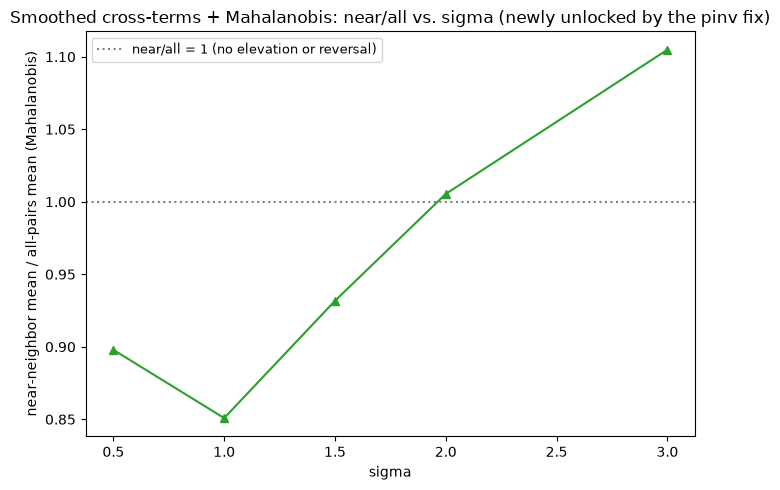

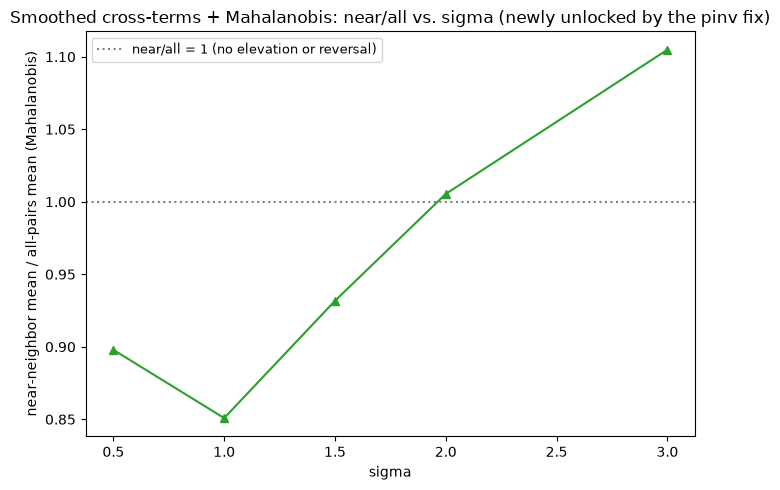

In [2]:
import json
with open("results/smoothing_sweep_results.json") as f:
    _sweep_results = json.load(f)

mahalanobis_rows = []
for sigma_str, r in _sweep_results.items():
    m = r["mahalanobis_ratio_summary"]
    if m is not None:
        mahalanobis_rows.append({
            "sigma": float(sigma_str),
            "min_cv": r["min_cv"],
            "selected_epsilon": r["selected_epsilon"],
            "mahalanobis_near_over_all": m["near_neighbor_mean"] / m["all_pairs_mean"],
        })

mahalanobis_df = pd.DataFrame(mahalanobis_rows).sort_values("sigma").set_index("sigma")
display(mahalanobis_df)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mahalanobis_df.index, mahalanobis_df["mahalanobis_near_over_all"], marker="^", color="tab:green")
ax.axhline(1.0, color="gray", linestyle=":", label="near/all = 1 (no elevation or reversal)")
ax.set_xlabel("sigma")
ax.set_ylabel("near-neighbor mean / all-pairs mean (Mahalanobis)")
ax.set_title("Smoothed cross-terms + Mahalanobis: near/all vs. sigma (newly unlocked by the pinv fix)")
ax.legend(fontsize=9)
fig.tight_layout()
display(fig)

## New section: within/between-class separation (a different question from the Lipschitz near/all ratio)

Everything above asks whether a *model's* margin sensitivity is elevated on near-neighbor pairs --
a statement about the model, using the distance metric only to pick which pairs count as
"near-neighbor". This section asks a completely different question, with no model or margin
involved at all: **using only true digit labels, does a given distance metric intrinsically place
different digits farther apart than same-digit pairs?** Computed as `mean(between-class distance) /
mean(within-class distance)` on a stratified 300-point subsample (`run_experiment.py::
class_separation_ratio`/`run_class_separation_check`) -- higher is better class separation. Checked
for exactly 4 metrics: plain Euclidean on raw pixels; `local_patch_cross_terms` + Euclidean
(unsmoothed); `smoothed_cross_terms_embedding` + Euclidean at `sigma=1`; and the same `sigma=1`
embedding + Mahalanobis -- the last one only meaningful since the pinv fix + `RADIUS_MULTIPLIER=5`
change made it a valid, passing metric at all.

In [3]:
from mnist_lipschitz.run_experiment import run_class_separation_check

class_sep_result = run_class_separation_check(n_points=300, seed=SEED, verbose=True)

class_sep_rows = [
    {"metric": name, "within_mean": r["within_mean"], "between_mean": r["between_mean"], "ratio": r["ratio"]}
    for name, r in class_sep_result["results"].items()
]
class_sep_df = pd.DataFrame(class_sep_rows).sort_values("ratio", ascending=False).set_index("metric")
display(class_sep_df)

  euclidean_raw_pixels: within=8.8926  between=10.3919  ratio=1.1686


  cross_terms_unsmoothed_euclidean: within=17.9966  between=20.5782  ratio=1.1434


  cross_terms_sigma1_euclidean: within=10.9737  between=13.2838  ratio=1.2105


  cross_terms_sigma1_mahalanobis: within=18.1509  between=18.7107  ratio=1.0308


,within_mean,between_mean,ratio
metric,,,
cross_terms_sigma1_euclidean,10.973657,13.283822,1.210519
euclidean_raw_pixels,8.892580,10.391879,1.168601
cross_terms_unsmoothed_euclidean,17.996645,20.578231,1.143448
cross_terms_sigma1_mahalanobis,18.150906,18.710664,1.030839


**Finding: smoothed cross-terms + Euclidean is the best class-separator; Mahalanobis, despite being
the hardest metric to get working, is the worst of the four.**

| rank | metric | between/within ratio |
|---|---|---|
| 1 | smoothed cross-terms (sigma=1) + Euclidean | 1.2105 |
| 2 | plain Euclidean (raw pixels) | 1.1686 |
| 3 | unsmoothed cross-terms + Euclidean | 1.1434 |
| 4 | smoothed cross-terms (sigma=1) + Mahalanobis | 1.0308 |

This is a different, and in one respect opposite, picture from the Lipschitz near/all analysis
above: there, Mahalanobis was interesting specifically *because* it reverses the Euclidean-family
pattern (near/all < 1). Here, plain intrinsic class separation, Mahalanobis is the weakest of the
four -- consistent with the same underlying mechanism (`mahalanobis_flip_mechanism.md`): Mahalanobis
distance amplifies low-variance pixel directions and downweights high-variance ones, but the
directions that best separate *different digit classes* from each other are disproportionately the
high-variance ones (stroke position/shape, which varies a lot both within and across classes) --
downweighting them costs Mahalanobis some of its ability to tell classes apart, even though it's
the metric that took by far the most work (ridge-regularization tuning, the truncated-eigenvalue
alternative, this whole numerical-bug saga) to get working at all here.

**Practical takeaway**: smoothing before computing cross-terms, even under plain Euclidean
distance, is a straightforward improvement over both raw pixels and unsmoothed cross-terms for pure
class separation -- no Mahalanobis machinery required. The Mahalanobis metric's value in this
project was never about being a better class-separator; it's specifically about the near/all
reversal pattern it produces on near-neighbor pairs, a different and unrelated property.